In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

In [2]:
purchase_data = pd.read_csv(r'D:\IBM Lab\purchase.csv')
customer_data = pd.read_csv(r'D:\IBM Lab\customer.csv')

In [3]:
purchase_data.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022


In [4]:
customer_data.head(5)

,customer_id,first_name,last_name,gender,age,country,income
0,CS00001,Isadora,Porto,Female,19,Brazil,117196
1,CS00002,Hugo,Carreño,Male,33,Chile,49256
2,CS00003,René,Olivera,Male,65,Mexico,33434
3,CS00004,Luiz Henrique,Pinto,Male,55,Brazil,75302
4,CS00005,Leonardo,Monteiro,Male,19,Brazil,32280


In [5]:
merged_data = pd.merge(purchase_data, customer_data, on='customer_id')

In [6]:
merged_data.head(5)

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,first_name,last_name,gender,age,country,income
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020,Isadora,Porto,Female,19,Brazil,117196
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022,Hugo,Carreño,Male,33,Chile,49256
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021,René,Olivera,Male,65,Mexico,33434
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020,Luiz Henrique,Pinto,Male,55,Brazil,75302
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022,Leonardo,Monteiro,Male,19,Brazil,32280


In [7]:
merged_data['revenue'] = (merged_data['price'] - merged_data['discount']) * merged_data['quantity'] + merged_data['tax']
top_products = merged_data.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(5)

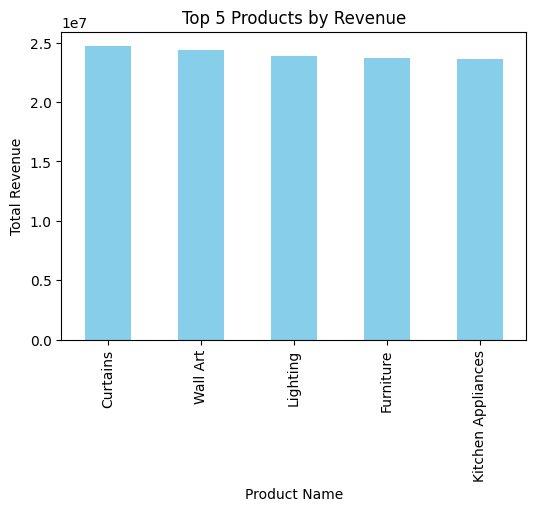

In [8]:
plt.figure(figsize=(6, 4))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.show()

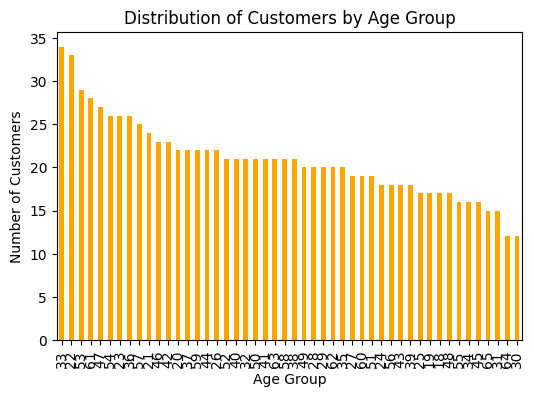

In [9]:
plt.figure(figsize=(6, 4))
customer_data['age'].value_counts().plot(kind='bar', color='orange')
plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

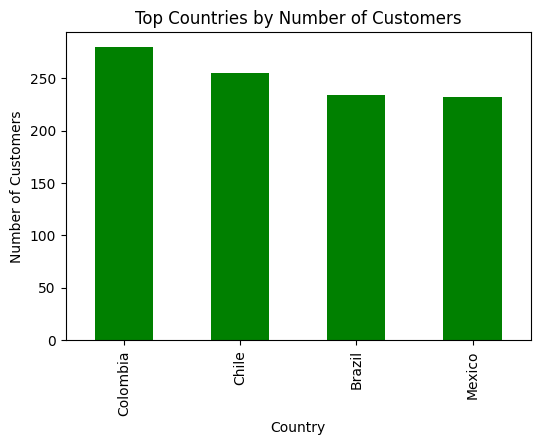

In [10]:
top_countries = customer_data['country'].value_counts().head(5)
plt.figure(figsize=(6, 4))
top_countries.plot(kind='bar', color='green')
plt.title('Top Countries by Number of Customers')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
merged_data['shipping_duration'] = (pd.to_datetime(merged_data['shipping_date']) - pd.to_datetime(merged_data['order_date'])).dt.days
within_3_days = merged_data[merged_data['shipping_duration'] <= 3]['shipping_cost']
above_3_days = merged_data[merged_data['shipping_duration'] > 3]['shipping_cost']

C:\Users\user\AppData\Local\Temp\ipykernel_18412\2210683581.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_data['shipping_duration'] = (pd.to_datetime(merged_data['shipping_date']) - pd.to_datetime(merged_data['order_date'])).dt.days
C:\Users\user\AppData\Local\Temp\ipykernel_18412\2210683581.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  merged_data['shipping_duration'] = (pd.to_datetime(merged_data['shipping_date']) - pd.to_datetime(merged_data['order_date'])).dt.days


In [12]:
male_income = customer_data[customer_data['gender'] == 'Male']['income']
female_income = customer_data[customer_data['gender'] == 'Female']['income']
t_stat, p_val_t = ttest_ind(male_income, female_income)
print("T-Test for Income by Gender:")
print(f"T-Statistic: {t_stat}, P-Value: {p_val_t}")

T-Test for Income by Gender:
T-Statistic: -0.2447688626238352, P-Value: 0.8066856706219072


In [13]:
product_gender_table = pd.crosstab(merged_data['product_name'], merged_data['gender'])
chi2_stat, p_val_chi2, dof, expected = chi2_contingency(product_gender_table)
print("Chi-Square Test for Product Categories and Gender:")
print(f"Chi2-Statistic: {chi2_stat}, P-Value: {p_val_chi2}")

Chi-Square Test for Product Categories and Gender:
Chi2-Statistic: 22.592714742452966, P-Value: 0.7948435792013748


In [14]:
merged_data['total_cost'] = merged_data['revenue'] + merged_data['shipping_cost']
income_cost_corr = merged_data[['income', 'total_cost']].corr().iloc[0, 1]
print(f"Correlation between Income and Total Cost: {income_cost_corr}")

Correlation between Income and Total Cost: 0.0031308858080808357


1. T-Test for Income by Gender T-Statistic: -0.2447 P-Value: 0.8067 Interpretation: Since the p-value (0.8067) is greater than the typical significance level (e.g., 0.05), we fail to reject the null hypothesis. This means there is no statistically significant difference in income between genders.

2. Chi-Square Test for Product Categories and Gender Chi2-Statistic: 22.5927 P-Value: 0.7948 Interpretation: The high p-value (0.7948) indicates that we fail to reject the null hypothesis. There is no significant association between product categories and gender.

3. Correlation between Income and Total Cost Correlation Coefficient: 0.0031 Interpretation: The correlation coefficient is very close to zero, suggesting no linear relationship between income and total cost. This means income does not appear to influence the total cost in the dataset.

Recommendations Based on Insights

Insight from T-Test (Income by Gender): The t-test shows no significant difference in income levels between genders (p-value = 0.81). Recommendation: Avoid gender-based pricing or discount strategies. Instead, design universal promotional offers that appeal to all demographics.

Insight from Chi-Square Test (Product Categories and Gender): The chi-square test indicates no significant association between product categories and gender (p-value = 0.79).

Recommendation: Focus on product performance data rather than gender-based preferences. Promote top-selling products universally to maximize sales.

Insight from Correlation Analysis (Income and Total Cost): The correlation between income and total cost is negligible (r = 0.003), suggesting that spending patterns are not strongly influenced by income levels.

Recommendation: Implement strategies to encourage higher spending per transaction, such as bundle offers, bulk purchase discounts, or free shipping thresholds.

General Insight: If additional demographic variables (e.g., age, region) are available, further hypothesis testing can reveal significant patterns. Recommendation: Tailor campaigns or product offerings to segments that show statistically significant differences in spending behavior or preferences.